# <span style="color:green"> Numerical Simulation Laboratory (NSL)
#### Emma Franco
## <span style="color:blue">  Lecture 6</span>
### <span style= "color: black" > Es06.1

In questo esercizio si vuole studiare il comportamento termodinamico del modello di Ising monodimensionale al variare della temperatura $T$, nel range $\left[0.5;2.0\right]$ , considerando un sistema di $N=50$ spin con costante di accoppiamento $J=1$.

Le grandezze di interesse sono (espresse in unità ridotte con $k_B = 1$ e come già detto $J=1$):

1. $U(N,T) = \langle H \rangle_{h=0}$
2. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$ 
3. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
4. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

Nel modello considerato, gli spin sono disposti lungo una catena monodimensionale e ciascuno spin interagisce solo con i suoi primi vicini. 

L'Hamiltoniana del sistema è

$$
H = -J \sum_{i=1}^{N} s_i s_{i+1}
    - h \sum_{i=1}^{N} s_i ,
$$

dove $s_i = \pm 1$ rappresenta il valore assunto da ogni spin ed $h$ l'eventuale campo magnetico esterno. 

Si considerano condizioni periodiche al contorno, cioè, $s_{N+1} = s_1$, in modo da non avere effetti di bordo e simulare una catena infinita.

Le quantità $U$, $C$ e $\chi$ vengono calcolate a campo esterno nullo, $h=0$, mentre la magnetizzazione $M$ viene valutata in presenza di un campo esterno pari a $h=0.02$ poiché in 1D sarebbe altrimenti nulla.

Per ricavare queste grandezze fisiche è necessario campionare correttamente le configurazioni di spin secondo la distribuzione di Boltzmann alla temperatura considerata:

$$
P(\{s_i\}) \propto e^{-\beta H(\{s_i\})}.
$$

In questo esercizio il campionamento viene effettuato utilizzando due algoritmi Monte Carlo: l'algoritmo di Metropolis, già discusso nell'Esercitazione 5, e l'algoritmo di Gibbs.

Entrambi gli algoritmi generano una sequenza di configurazioni di spin rappresentative dell'ensemble canonico. La differenza principale  tra i due algoritmi riguarda il modo in cui viene aggiornato il singolo spin in quanto nel metodo di Gibbs lo spin selezionato viene ricampionato direttamente dalla probabilità condizionata determinata dagli altri spin e la mossa di flip viene quindi accettata sempre. 

Nel caso del modello di Ising 1D, poiché l'interazione è solo tra primi vicini, la probabilità dipende soltanto dagli spin adiacenti $s_{i-1}$ e $s_{i+1}$ e quindi la probabilità di assegnare allo spin il valore $\pm1$ è 

$$
P(s_i = \pm 1 \mid \{s_{j \neq i}\}) =
\frac{
e^{-\beta E(s_i=\pm 1)}
}{
e^{-\beta E(s_i=+1)} + e^{-\beta E(s_i=-1)}
}
$$

quindi

$$
P(s_i = \pm1) =
\frac{1}{
1 + \exp\left[\mp2\beta\left(J(s_{i-1}+s_{i+1})+h\right)\right]
}
$$


Una parte fondamentale dell'esercizio è l'equilibrazione del sistema, che deve essere eseguita per ogni valore di temperatura considerato. Il range di temperatura $T \in [0.5, 2.0]$ è stato campionato utilizzando un passo $\Delta T = 0.25$.

Per ciascun valore di temperatura, l'equilibrazione è stata effettuata utilizzando $N_{\text{blocks}} = 2000$ blocchi, con 10 step per blocco. Questa procedura permette di scartare la fase iniziale della simulazione, durante la quale le configurazioni di spin non sono ancora rappresentative della distribuzione di equilibrio alla temperatura fissata.

L'equilibrazione è stata eseguita separatamente per il caso a campo nullo, $h=0$, usato per il calcolo di $U/N$, $C_V/N$ e $\chi/N$, e per il caso con campo esterno $h=0.02$, necessario per il calcolo della magnetizzazione $M/N$.


Qui sotto viene mostrato l'andamento della media progressiva delle varie grandezze fisiche durante l'equilibrazione per $T=2$, sia per il metodo Gibbs che per il metodo Metropolis, in funzione del numero di blocchi. E' stato scelto di mostrare l'andamento della media progressiva e non quello della media per blocco poiché quest'ultima presenta fluttuazioni più marcate e risulta quindi meno chiara dal punto di vista grafico. Nonostante ciò però bisogna tenere conto del fatto che nei valori della media progressiva rimane sempre presente il contributo della fase iniziale non equilibrata.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot(filename_metropolis, y_name, filename_gibbs=None, title=None, ax=None, legend=False):
    
    if title is None:
        title = y_name

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 10))
        single_plot = True
    else:
        single_plot = False

    x_name = "Number of blocks"

    # ---------- METROPOLIS ----------
    data = np.loadtxt(filename_metropolis, skiprows=1)

    block = data[:, 0]
    x = block
    y = data[:, 2]
    error = data[:, 3]

  
    ax.plot(x, y, marker="o", linestyle="--", markersize=3, linewidth=1, label="Metropolis")

    # ---------- GIBBS ----------
    if filename_gibbs is not None:
        data = np.loadtxt(filename_gibbs, skiprows=1)

        block = data[:, 0]
        x = block
        y = data[:, 2]
        error = data[:, 3]

       
        ax.plot(x, y, marker="o", linestyle="--", markersize=3, linewidth=1, label="Gibbs")

    ax.set_xlabel(x_name, fontsize=12)
    ax.set_ylabel(y_name, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)

    if legend is not False:
        ax.legend(fontsize=10)

    if single_plot:
        plt.show()

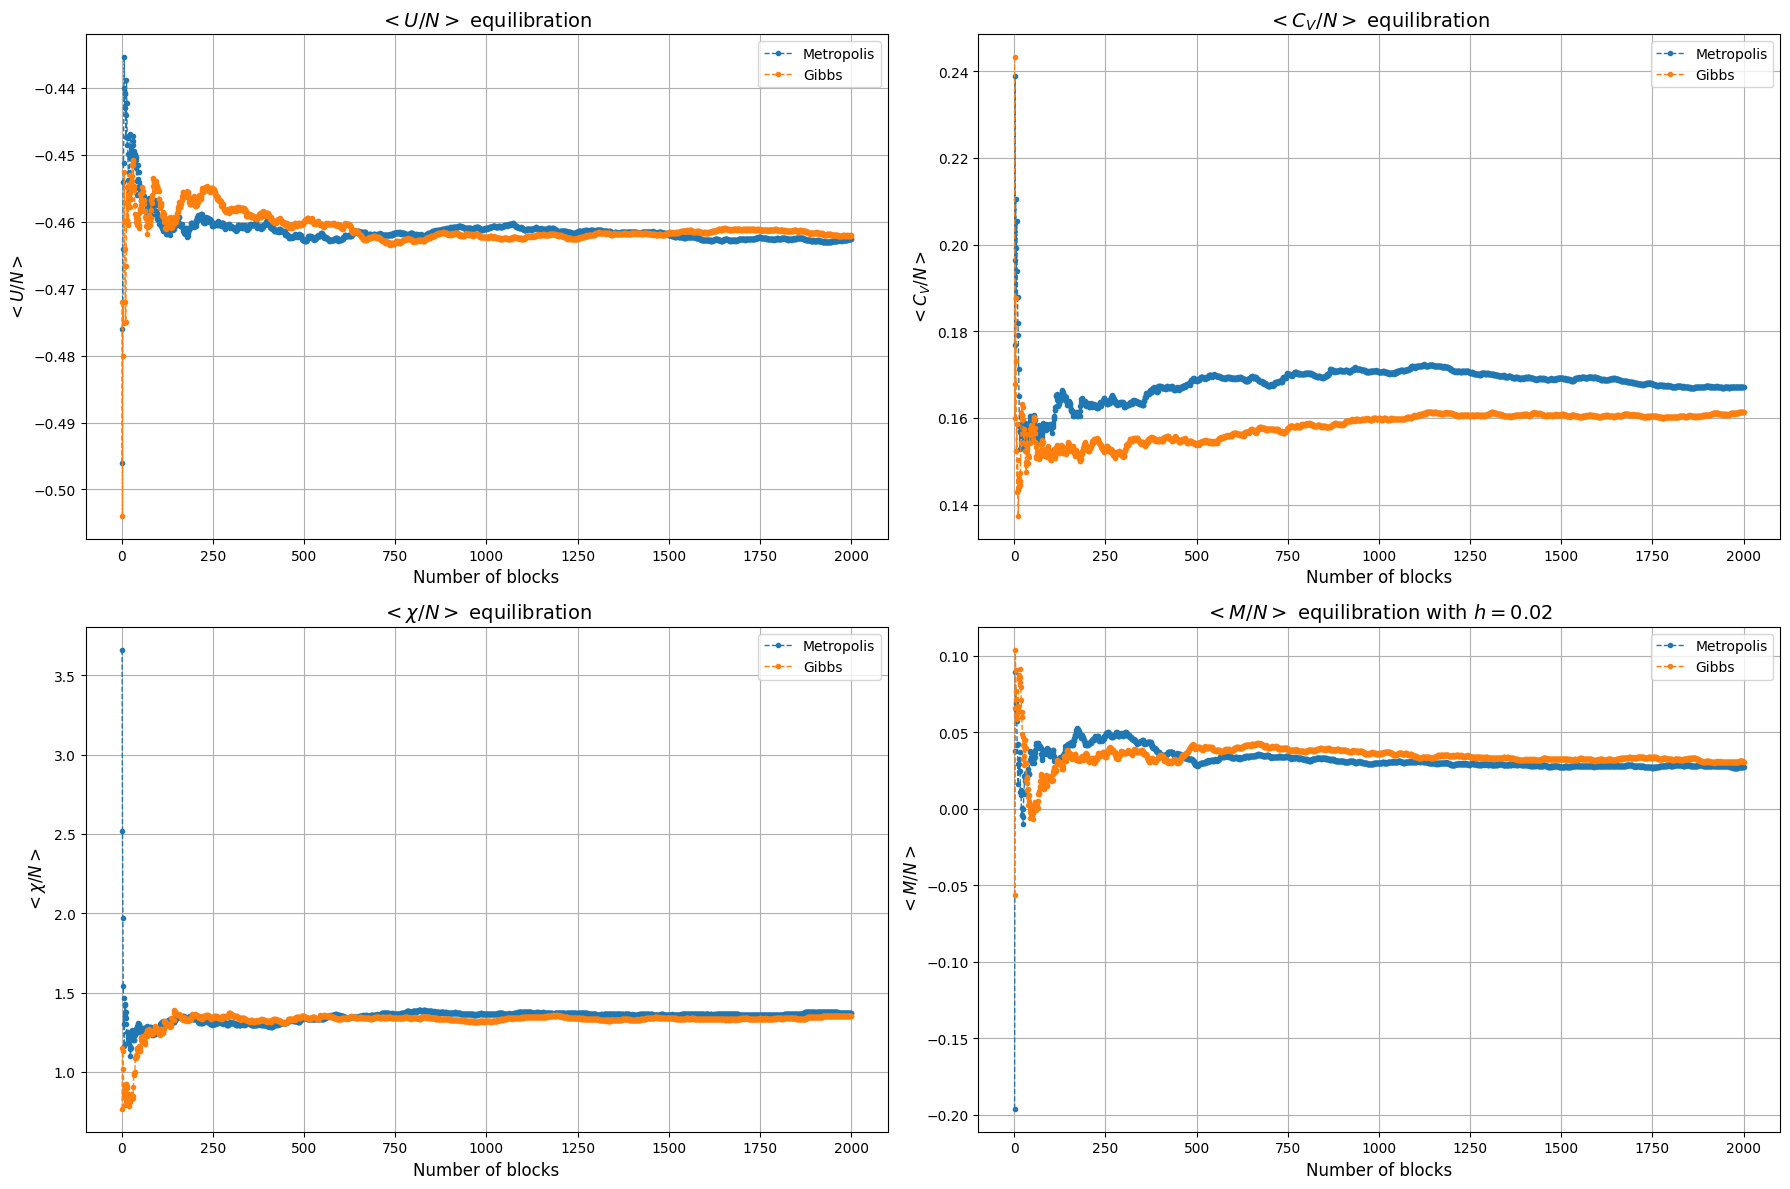

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.ravel()

plot("NSL_SIMULATOR/OUTPUT/Metropolis/Equilibration/total_energy.dat", r"$<U/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/Equilibration/total_energy.dat", title=r"$<U/N>$ equilibration", ax=axs[0], legend=True)
plot("NSL_SIMULATOR/OUTPUT/Metropolis/Equilibration/specific_heat.dat", r"$<C_V/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/Equilibration/specific_heat.dat", title=r"$<C_V/N>$ equilibration", ax=axs[1], legend=True)
plot("NSL_SIMULATOR/OUTPUT/Metropolis/Equilibration/susceptibility.dat", r"$<\chi/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/Equilibration/susceptibility.dat", title=r"$<\chi/N>$ equilibration", ax=axs[2], legend=True)
plot("NSL_SIMULATOR/OUTPUT/Metropolis/Equilibration/magnetization.dat",  r"$<M/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/Equilibration/magnetization.dat", title=r"$<M/N>$ equilibration with $h=0.02$", ax=axs[3], legend=True)

plt.tight_layout()
plt.show()

Per eseguire l'analisi descritta sopra, la simulazione è stata condotta partendo dalla temperatura più alta, $T=2.0$, e diminuendo progressivamente verso la la temperatura più bassa.

Questa scelta è motivata dal fatto che, a temperature più alte, le fluttuazioni termiche sono maggiori e il sistema esplora più facilmente lo spazio delle configurazioni. In queste condizioni è quindi meno probabile che la simulazione rimanga bloccata in configurazioni ordinate o in domini metastabili.

Dopo aver equilibrato e simulato il sistema a una certa temperatura, la configurazione finale è stata usata come configurazione iniziale per la temperatura successiva. In questo modo si ottiene una procedura di raffreddamento graduale del sistema.

Come detto prima per ogni nuovo valore di temperatura è stata comunque eseguita una nuova fase di equilibrazione, poiché una configurazione equilibrata a una certa temperatura non è automaticamente rappresentativa dell'equilibrio alla temperatura successiva.

La simulazione è stata eseguita considerando $100$ blocchi da $10000$ steps e nei grafici ogni punto rappresenta il valore della media progressiva del blocco finale con il rispettivo errore. I punti ricavati dalla simulazione vengono confrontati con l'andamento teorico delle varie grandezze fisiche.

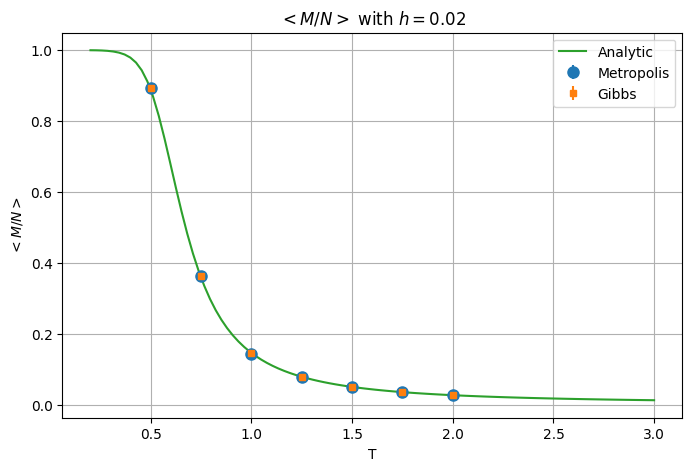

In [7]:
#Magnetization

import matplotlib.pyplot as plt
import numpy as np

#Theoretical curve
points=100
T = np.linspace(0.2,3.0,num=points)
h=0.02 #external field
b = 1/T
J = 1.0
Ns = 50

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)


def graph(filename_metro, ylabel, filename_gibbs=None, analytic_T=None, analytic_y=None, title=None):
    
    plt.figure(figsize=(8, 5))

    # Metropolis
    data = np.loadtxt(filename_metro)

    temp = data[:, 0]
    values = data[:, 1]
    errors = data[:, 2]

    plt.errorbar(temp, values, yerr=errors, fmt="o", label="Metropolis", markersize = 8)

    # Gibbs
    if filename_gibbs is not None:
        data_gibbs = np.loadtxt(filename_gibbs)

        temp_gibbs = data_gibbs[:, 0]
        values_gibbs = data_gibbs[:, 1]
        errors_gibbs = data_gibbs[:, 2]

        plt.errorbar(temp_gibbs, values_gibbs, yerr=errors_gibbs, fmt="s", label="Gibbs", markersize = 4)

    # Theoretical curve
    if analytic_T is not None and analytic_y is not None:
        plt.plot(analytic_T, analytic_y, label="Analytic")

    plt.xlabel("T")
    plt.ylabel(ylabel)

    if title is None:
        title = ylabel

    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

graph("NSL_SIMULATOR/OUTPUT/Metropolis/magnetization.dat", r"$<M/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/magnetization.dat", analytic_T=T, analytic_y=M, title=r"$<M/N>$ with $h=0.02$")

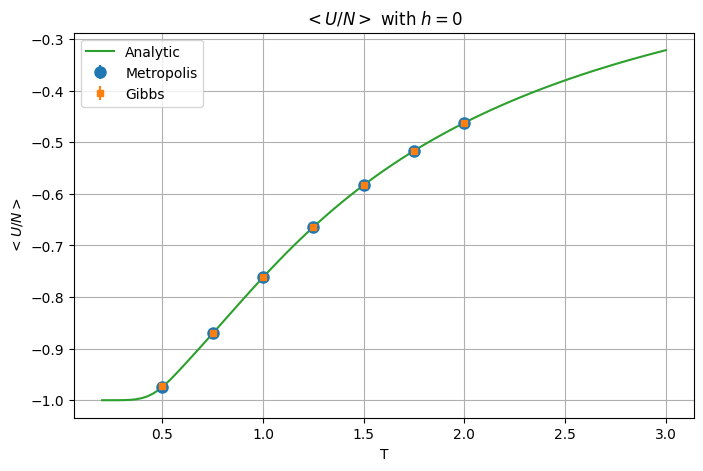

In [8]:
#Internal Energy

#Theoretical curve
th = np.tanh(J / T)
thN = th**Ns
ch = 1 / th

e = -J * (th + ch * thN) / (1 + thN)

graph("NSL_SIMULATOR/OUTPUT/Metropolis/total_energy.dat", r"$<U/N>$", filename_gibbs = "NSL_SIMULATOR/OUTPUT/Gibbs/total_energy.dat", analytic_T=T, analytic_y=e, title=r"$<U/N>$ with $h=0$")

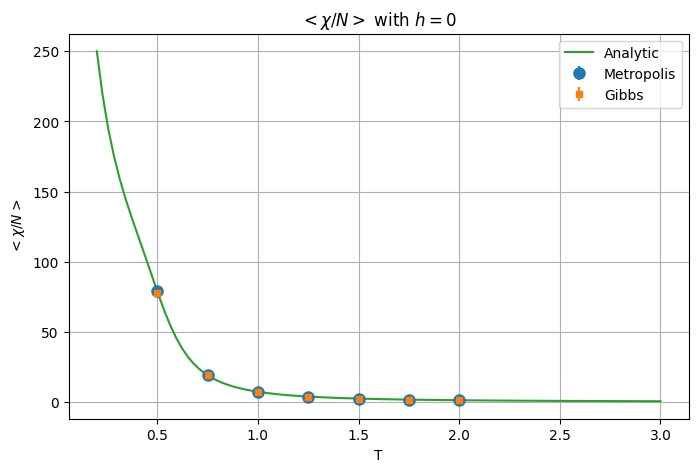

In [9]:
#Susceptibility

#Theoretical curve
X = b*np.exp(2*b*J)*(1-thN)/(1+thN)
graph('NSL_SIMULATOR/OUTPUT/Metropolis/susceptibility.dat', r"$<χ/N>$", filename_gibbs = 'NSL_SIMULATOR/OUTPUT/Gibbs/susceptibility.dat',  analytic_T=T, analytic_y=X, title=r"$<χ/N>$ with $h=0$")


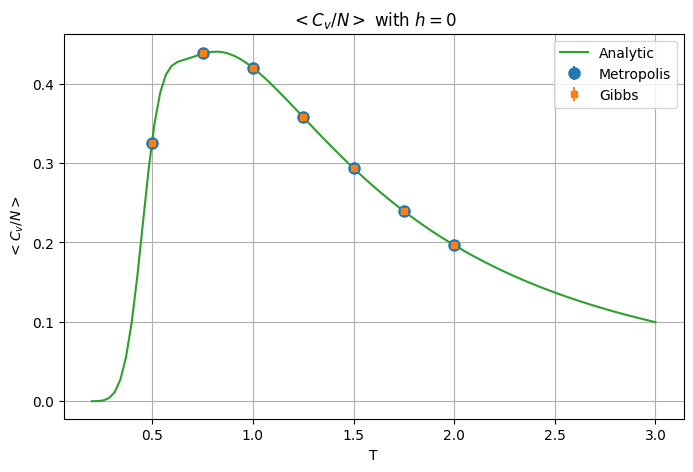

In [56]:
#Calore specifico

#curva analitica

heat=((b*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
graph('NSL_SIMULATOR/OUTPUT/Metropolis/specific_heat.dat', r"$<C_v/N>$", filename_gibbs = 'NSL_SIMULATOR/OUTPUT/Metropolis/specific_heat.dat', analytic_T=T, analytic_y=heat, title=r"$<C_v/N>$ with $h=0$")

Dai grafici si può notare una perfetta compatibilità tra i valori ricavati con il metodo di Metropolis ed il metodo di Gibbs ed ottimo accordo con gli andamenti teorici.